# Interpolate

Let's say you have a set of images of a certain pixel height and width $(h, w)$, and you want to change them to a different size $(h', w')$. [`torch.interpolate`](https://docs.pytorch.org/docs/2.12/generated/torch.nn.functional.interpolate.html) provides a way to do this with many different options for doing it in different ways.

Let's generate a small image and see what the different interpolation options do to it. We're going to focus on scaling only in one dimension, so our image will just be a row of pixels. So that we can clearly see what each interpolation method does, we'll use only six pixels, the six primary and secondary colors, plus black and white.

In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MultipleLocator

def gen_image():
    c1 = torch.tensor([[1., 0, 0, 0, 0., 1., 1., 1.]])
    c2 = torch.tensor([[0, 1., 0, 0, 1., 0., 1., 1.]])
    c3 = torch.tensor([[0, 0, 1., 0, 1., 1., 0., 1.]])
    im = torch.stack([c1, c2, c3])
    return im

def draw_image(im, ax):
    C = im.shape[0]
    assert C == 3 or C == 1
    h = im.shape[1]
    w = im.shape[2]
    for y in range(h):
        for x in range(w):
            color = im[:, y, x].tolist()
            if C == 1:
                color = color * 3
            square = patches.Rectangle((x, y), 1, 1, alpha=1, color=color)

            ax.add_patch(square)
            ax.plot([x+0.5], [y+0.5], marker='o', color='black')
    ax.set_xlim(0, w)
    ax.set_ylim(0, h)

def show_images(*ims, titles=None):
    if titles is None:
        titles = [None] * len(ims)
    else:
        assert len(titles) == len(ims)
    _, axs = plt.subplots(len(ims), 1, figsize=(10, 2 * len(ims)))
    plt.subplots_adjust(hspace=0.5) 

    for im, title, ax in zip(ims, titles, axs):
        draw_image(im, ax)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.yaxis.set_major_locator(MultipleLocator(1))
        ax.grid(True, color='black')
        if title is not None:
            ax.set_title(title)
    plt.show()

Nearest interpolation is pretty much the simplest one. Below we're scaling the image up by a factor of 3, so the output image looks exactly the same, except that each color has 3 repeated pixels instead of just one.

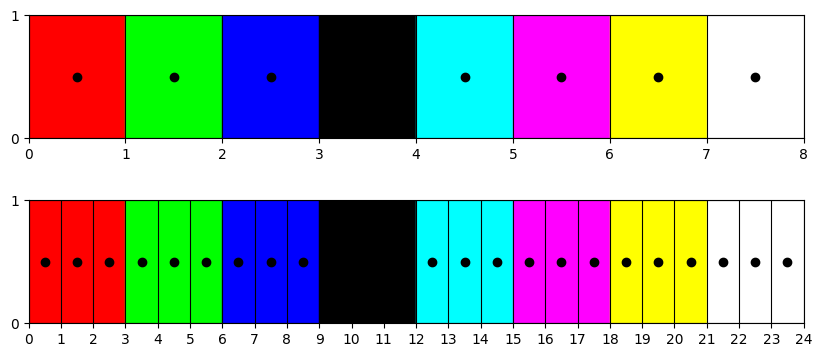

In [2]:
im1 = gen_image()
im2 = torch.nn.functional.interpolate(
    im1,
    scale_factor=(3,),
    mode='nearest'
)

show_images(im1, im2)

Notice that we've marked the center of each pixel with a dot. For all the interpolation methods, we map both the input and output spaces onto any flat coordinate space where the edges of the images are parallel, just like the above plot shows. In the horizontal axis of the plot, the edges of both images are lined up. (However, if `align_corners=True`, the output image's edges are aligned with the __centers__ of the first and last input pixels, rather than the outer edges. But in this document we'll assume `align_corners=False` for convenience.) Once the images are mapped onto this new coordinate space, we use the coordinates of the centers of the pixels to determine how to apply the interpolation.

For nearest interpolation, the color of an output pixel is the color of the input pixel whose center is closest. In the above image, we can clearly see that the centers of the first three pixels of the output are closest to the center of the first input pixel along the horizontal axis, so their colors match--and the same goes for each other set of three pixels in the output.

Below we scale the image down by a factor of 0.5, so the output has half as many pixels. With this scale factor, the centers of the output pixels are actually exactly in the middle between two of the input pixel's centers. In this situation, the tie breaker is to just pick the leftmost input pixel. The result is that the output skips every second pixel of the input.

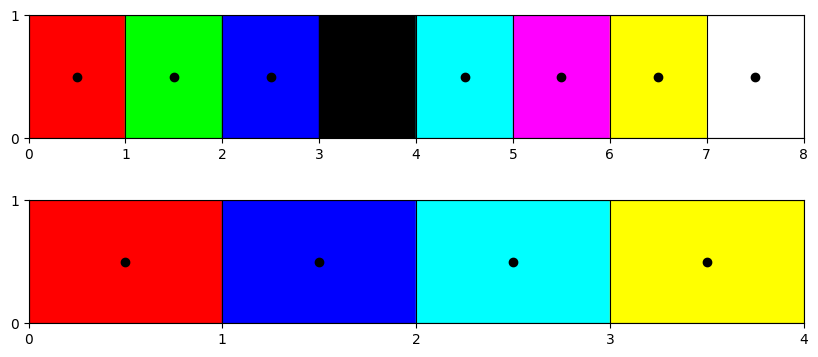

In [3]:
im1 = gen_image()
im2 = torch.nn.functional.interpolate(
    im1,
    scale_factor=(0.5,),
    mode='nearest'
)

show_images(im1, im2)

Now for linear interpolation. For this one, each output pixel is always a linear combination of two (or sometimes just one) of the input pixels, whichever two are closest and surrounding the output pixel's center. But there are edge cases--if an output pixel is not surrounded, either because its center is greater than or less than the centers of all the input pixels or because its coordinate exactly matches that of an input pixel, then nearest interpolation is applied to that output pixel.

Where $x_1$ and $x_2$ are the coordinates of the two input pixels that surround the output pixel, $v_1$ and $v_2$ are their values, and $x$ and $v$ are the coordinate and value of the output pixel, linear interpolation gives:

$$
v = \frac{|x_2 - x|}{|x_1 - x_2|} v_1 + \frac{|x_1 - x|}{|x_1 - x_2|} v_2
$$

Below, we use a scale factor of 2. Here, all of the output pixels, aside from the first and last, end up being a linear combination of the two nearest input pixels. The first and last pixels of the output are the same color as the first and last of the input, since they are not surrounded by two input pixels.

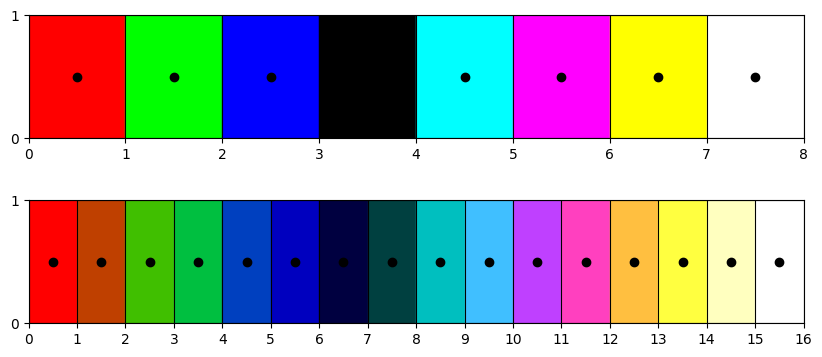

In [4]:
im1 = gen_image()
im2_linear_2 = torch.nn.functional.interpolate(
    im1,
    scale_factor=(2,),
    mode='linear',
)

show_images(im1, im2_linear_2)

Below we use a scale factor of 3. Now one out of every three output pixels lines up exactly with the center of one of the input pixels, so its color matches exactly. The other two thirds of the pixels (aside from the first and last) are a linear combination of the two nearest input pixels' centers, just like we saw in the last example.

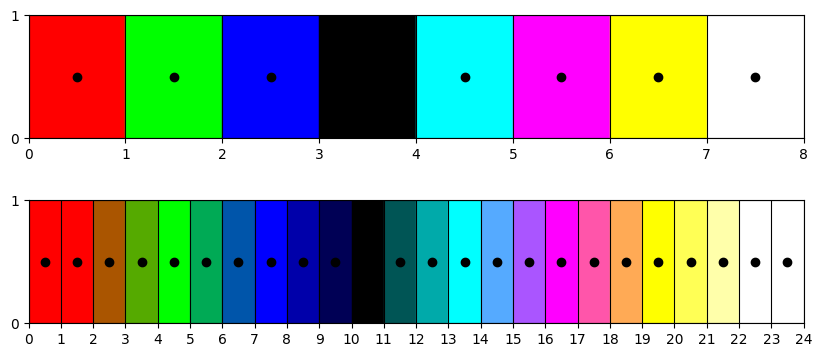

In [5]:
im1 = gen_image()
im2 = torch.nn.functional.interpolate(
    im1,
    scale_factor=(3,),
    mode='linear',
)

show_images(im1, im2)

Below we're using a scale factor of 0.5. Each output pixel is exactly in-between the two corresponding input pixels, so the output is the mean of the two inputs. Note that this does not have the same effect as mixing colors in the sense that we would normally think about it. Whereas we might normally think of mixing red $(1, 0, 0)$ and green $(0, 1, 0)$ to produce yellow $(1, 1, 0)$, we're actually taking the average to produce a dark yellow $(0.5, 0.5, 0)$.

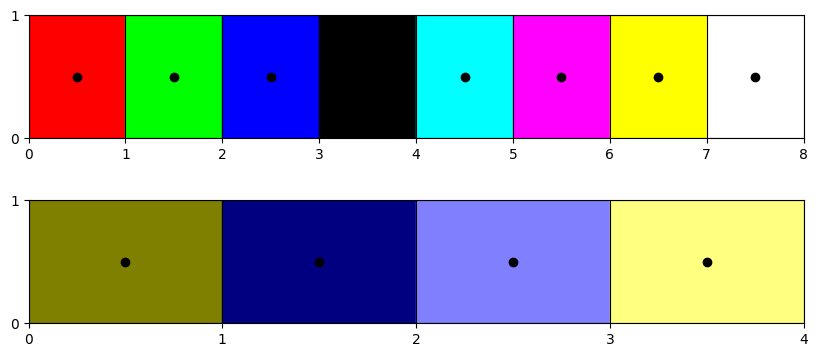

In [6]:
im1 = gen_image()
im2 = torch.nn.functional.interpolate(
    im1,
    scale_factor=(0.5,),
    mode='linear',
)

show_images(im1, im2)

Next is bilinear interpolation, which is the same as linear, except that it is generalized to two dimensions. We can think of it as applying a linear interpolation to all the rows of the input, and then applying a linear interpolation to all the columns, or vice-versa, the result is mathematically the same. 

Below we're using a bilinear interpolation with a scale factor of 2. We start with an input of size $(1, 8)$ and end up with an output of size $(2, 16)$. The two rows of the output are actually identical to the output of the linear interpolation with scale factor 2 that we did earlier--since the input only has one row, none of the output pixels are surrounded by two input pixels in the vertical dimension, so nearest interpolation is applied in the vertical dimension.


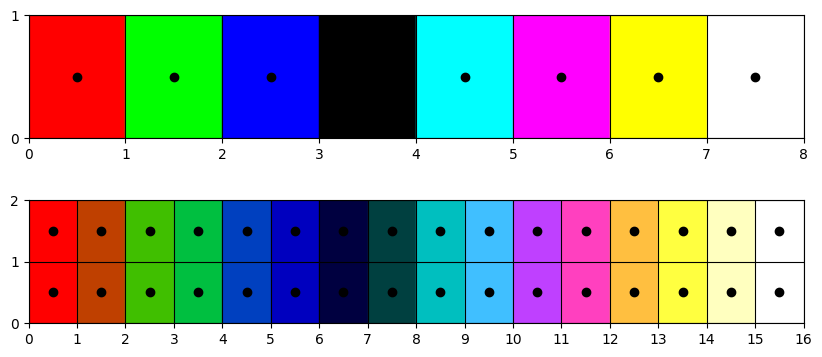

In [7]:
im1 = gen_image()
im2 = torch.nn.functional.interpolate(
    im1[None],
    scale_factor=(2, 2,),
    mode='bilinear',
)[0]

show_images(im1, im2)

assert torch.allclose(im2_linear_2[:, 0], im2[:, 0], atol=0, rtol=0)
assert torch.allclose(im2_linear_2[:, 0], im2[:, 1], atol=0, rtol=0)

To really see bilinear interpolation in action, we need to use an image with more than one row, so let's split the input into two rows and stack them on top of each other.

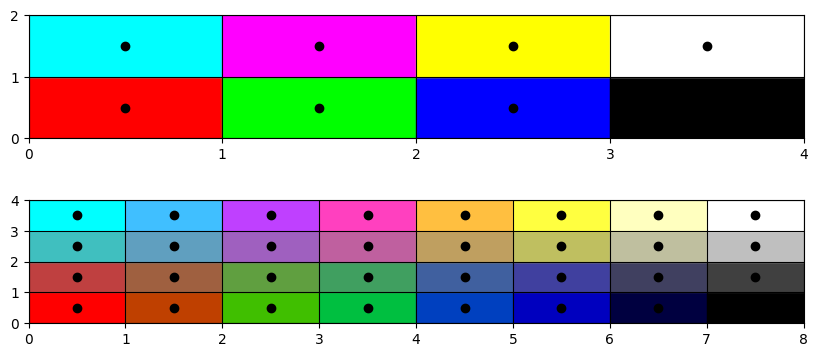

In [8]:
im1_2d = gen_image().reshape([3, 2, 4])

im2 = torch.nn.functional.interpolate(
    im1_2d[None],
    scale_factor=(2, 2,),
    mode='bilinear',
)[0]

show_images(im1_2d, im2)

The inputs and outputs are scaled such that their edges have the same coordinates in both the horizontal and vertical dimensions.

There is a feature for bilinear interpolation called antialiasing. When it's enabled, it is only applied for downsampling, when the scale factor is less than 1.

As we saw before, without antialiasing, if we're applying bilinear interpolation to a 1-D input, each output pixel is a linear combination of exactly 2 (or just 1 in the aforementioned edge cases) input pixels. But with antialiasing and downsampling, an output can depend on more than one input pixel.

Below we're using a scale factor larger than 1, so the output is the same with and without antialiasing.

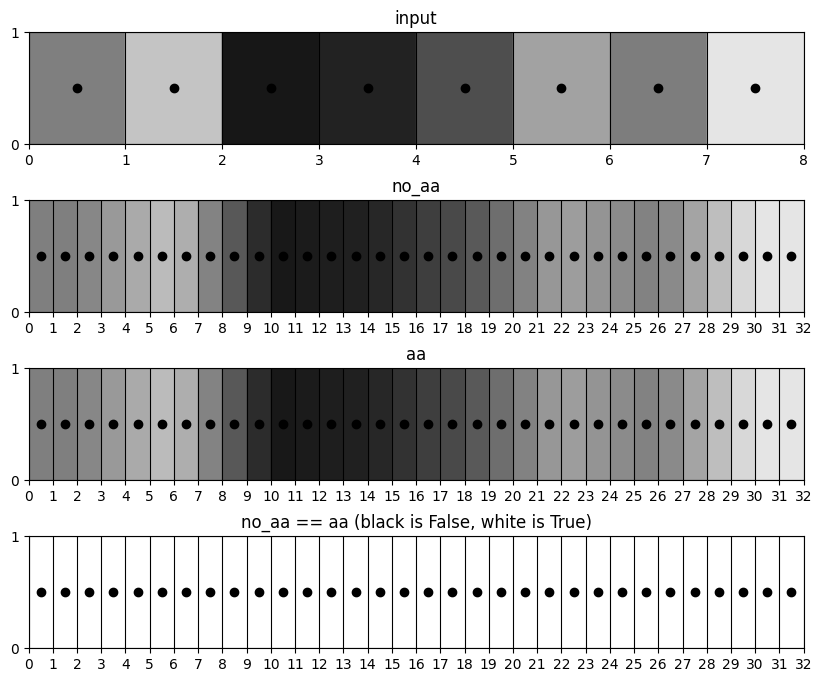

In [9]:
torch.manual_seed(0)
im1_bw = torch.rand(8)[None, None]

scale = 4

im2_no_aa, im2_aa = [
    torch.nn.functional.interpolate(
        im1_bw[None],
        scale_factor=(1, scale),
        mode='bilinear',
        antialias=aa
    )[0] for aa in [False, True]
]

show_images(
    im1_bw,
    im2_no_aa,
    im2_aa,
    (im2_no_aa - im2_aa).abs() < 0.001,
    titles=["input", "no_aa", "aa", "no_aa == aa (black is False, white is True)"]
)

But now if we use a scale less than 1, the output is different with and without antialiasing.

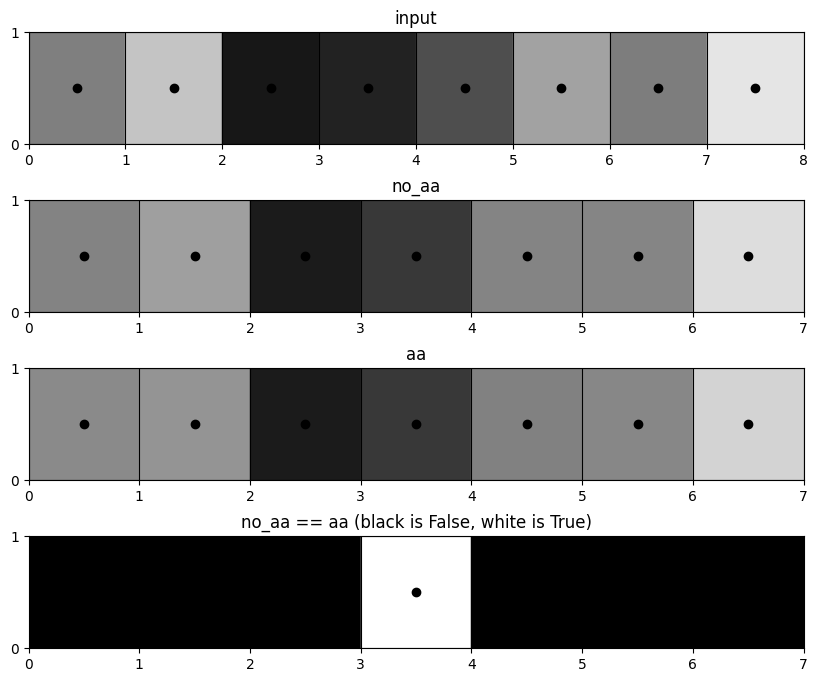

In [10]:
torch.manual_seed(0)
im1_bw = torch.rand(8)[None, None]

scale = 7/8

im2_no_aa, im2_aa = [
    torch.nn.functional.interpolate(
        im1_bw[None],
        scale_factor=(1, scale),
        mode='bilinear',
        antialias=aa
    )[0] for aa in [False, True]
]

show_images(
    im1_bw,
    im2_no_aa,
    im2_aa,
    (im2_no_aa - im2_aa).abs() < 0.001,
    titles=["input", "no_aa", "aa", "no_aa == aa (black is False, white is True)"]
)

Given a 1-D input $x$ and output $y$ with sizes $N_x$ and $N_y$, linear interpolation with antialiasing can be described by a matrix-vector multiplication:

$$
y_i = \sum_j^{N_x} w_{ij} x_j
$$

The calculation of the $w$ matrix is the complicated part. That is described by:

$$
w_{ij} = \frac{w_{ij}'}{\sum_j^{N_x} w_{ij}'}
\quad\quad
w_{ij}' = \begin{Bmatrix}
\max\Bigl(1 - \Bigl|\frac{j - c_i}{f}\Bigr|, 0\Bigr) & \text{if } j \in [j_{\min}(i), j_{\max}(i)] \\
0 & \text{else}
\end{Bmatrix}
$$

$$
j_{\min}(i) = \max(\lfloor c_i - f \rfloor, 0)
\quad\quad
j_{\max}(i) = \min(\lceil c_i + f \rceil, N_x - 1)
$$

$$
c_i = \frac{i + 1/2}{s} - \frac{1}{2}
\quad\quad
f = \max\Bigl(\frac{1}{s}, 1\Bigr)
\quad\quad
s = \frac{N_y}{N_x}
$$

Below is a Python example implementation of 1-D linear upsampling with antialiasing, and it gives the same result as PyTorch.

In [11]:
import numpy as np

def upsample_linear1d_aa_w(x, N_y):
    assert x.dim() == 1
    N_x = x.shape[0]
    s = N_y / N_x
    f = max(1 / s, 1)
    w = torch.zeros(N_y, N_x, dtype=x.dtype)

    for i in range(N_y):
        c_i = (i + 0.5) / s - 0.5
        j_min_i = max(int(np.floor(c_i - f)), 0)
        j_max_i = min(int(np.ceil(c_i + f)), N_x - 1)

        for j in range(N_x):
            if j >= j_min_i and j <= j_max_i:
                w[i, j] = max(1 - abs((j - c_i) / f), 0)

        w[i] /= w[i].sum()

    return w

def upsample_linear1d_aa(x, N_y):
    return upsample_linear1d_aa_w(x, N_y) @ x

Checking against PyTorch to make sure the forward is correct:

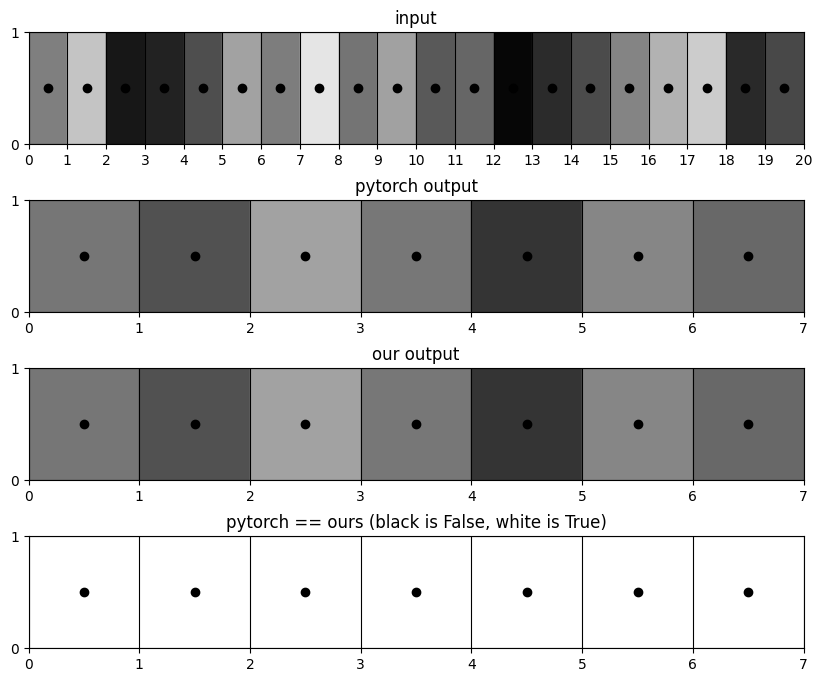

In [12]:
torch.manual_seed(0)

in_size = 20
out_size = 7

scale = out_size / in_size
x = torch.rand(in_size)[None, None]

y_check = torch.nn.functional.interpolate(
    x[None],
    scale_factor=(1, scale),
    mode='bilinear',
    antialias=True
)[0]
y = upsample_linear1d_aa(x[0, 0], out_size)[None, None]

assert torch.allclose(y_check, y)

show_images(
    x,
    y_check,
    y,
    (y_check - y).abs() < 0.001,
    titles=["input", "pytorch output", "our output", "pytorch == ours (black is False, white is True)"]
)

The calculation of the $w$ doesn't doesn't depend on the values of $x$. So the backward pass is simply the same as the backward pass for the vector in a matrix-vector multiplication:

$$
y_i = \sum_j^{N_x} w_{ij} x_j
\quad\rightarrow\quad
\nabla x_j = \sum_i^{N_y} (w^T)_{ij} \nabla y_i
$$

In [13]:
def upsample_linear1d_aa_backward(x, N_y, grad_y):
    w = upsample_linear1d_aa_w(x, N_y)
    return w.T @ grad_y

Checking against PyTorch to make sure the backward is correct:

In [14]:
torch.manual_seed(0)

in_size = 20
out_size = 7

scale = out_size / in_size
x = torch.rand(in_size)[None, None]

y = upsample_linear1d_aa(x[0, 0], out_size)[None, None]

y_grad = torch.rand_like(y)
x_grad = upsample_linear1d_aa_backward(x[0, 0], out_size, y_grad[0, 0])[None, None]

x.requires_grad_(True)

y_check = torch.nn.functional.interpolate(
    x[None],
    scale_factor=(1, scale),
    mode='bilinear',
    antialias=True
)[0]

y_check.backward(y_grad)
x_grad_check = x.grad[None]

assert torch.allclose(y_check, y)
assert torch.allclose(x.grad[None], x_grad)